In [62]:
# Task 1: Data Preparation

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [65]:
ccd = pd.read_csv(r"/content/drive/MyDrive/Google Colab/Saiket_Internship/datasets/Telco_Customer_Churn_Dataset  (3).csv")

In [66]:
print(ccd.head())

print(ccd.shape)

print(ccd.info())

print(ccd.describe())

print(ccd.isnull().sum())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [67]:
ccd['TotalCharges'] = pd.to_numeric(
    ccd['TotalCharges'],
    errors='coerce'
)

In [68]:
print(ccd.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [69]:
ccd['TotalCharges'].fillna(
    ccd['TotalCharges'].median(),
    inplace=True
)

/tmp/ipykernel_1480/3131693282.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ccd['TotalCharges'].fillna(


In [70]:
ccd.to_csv(r"/content/drive/MyDrive/Google Colab/Saiket_Internship/datasets/Telco_Customer_Churn_Cleaned.csv",
    index=False
)

In [71]:
ccd.drop('customerID', axis=1, inplace=True)

In [72]:
ccd = pd.get_dummies(
    ccd,
    drop_first=True
)

In [73]:
X = ccd.drop('Churn_Yes', axis=1)

y = ccd['Churn_Yes']

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [75]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 30)
(1409, 30)
(5634,)
(1409,)


In [76]:
ccd.to_csv(r"/content/drive/MyDrive/Google Colab/Saiket_Internship/datasets/Telco_Customer_Churn_train_test.csv",
    index=False
)

In [77]:
#Task 2 EXploratory Data Analysis

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [79]:
ccd = pd.read_csv(r"/content/drive/MyDrive/Google Colab/Saiket_Internship/datasets/Telco_Customer_Churn_Cleaned.csv")

In [80]:
churn_rate = (
    ccd['Churn']
    .value_counts(normalize=True)
    * 100
)

print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


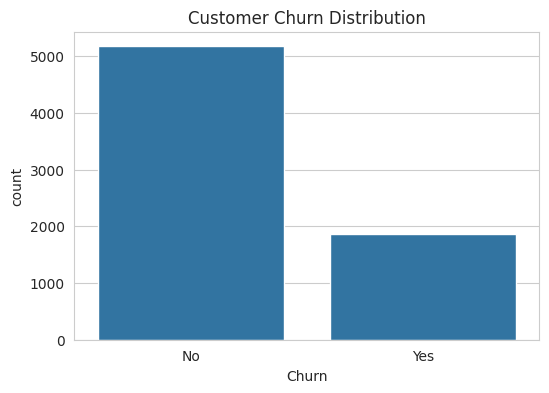

In [81]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=ccd,
    x='Churn'
)

plt.title('Customer Churn Distribution')
plt.show()

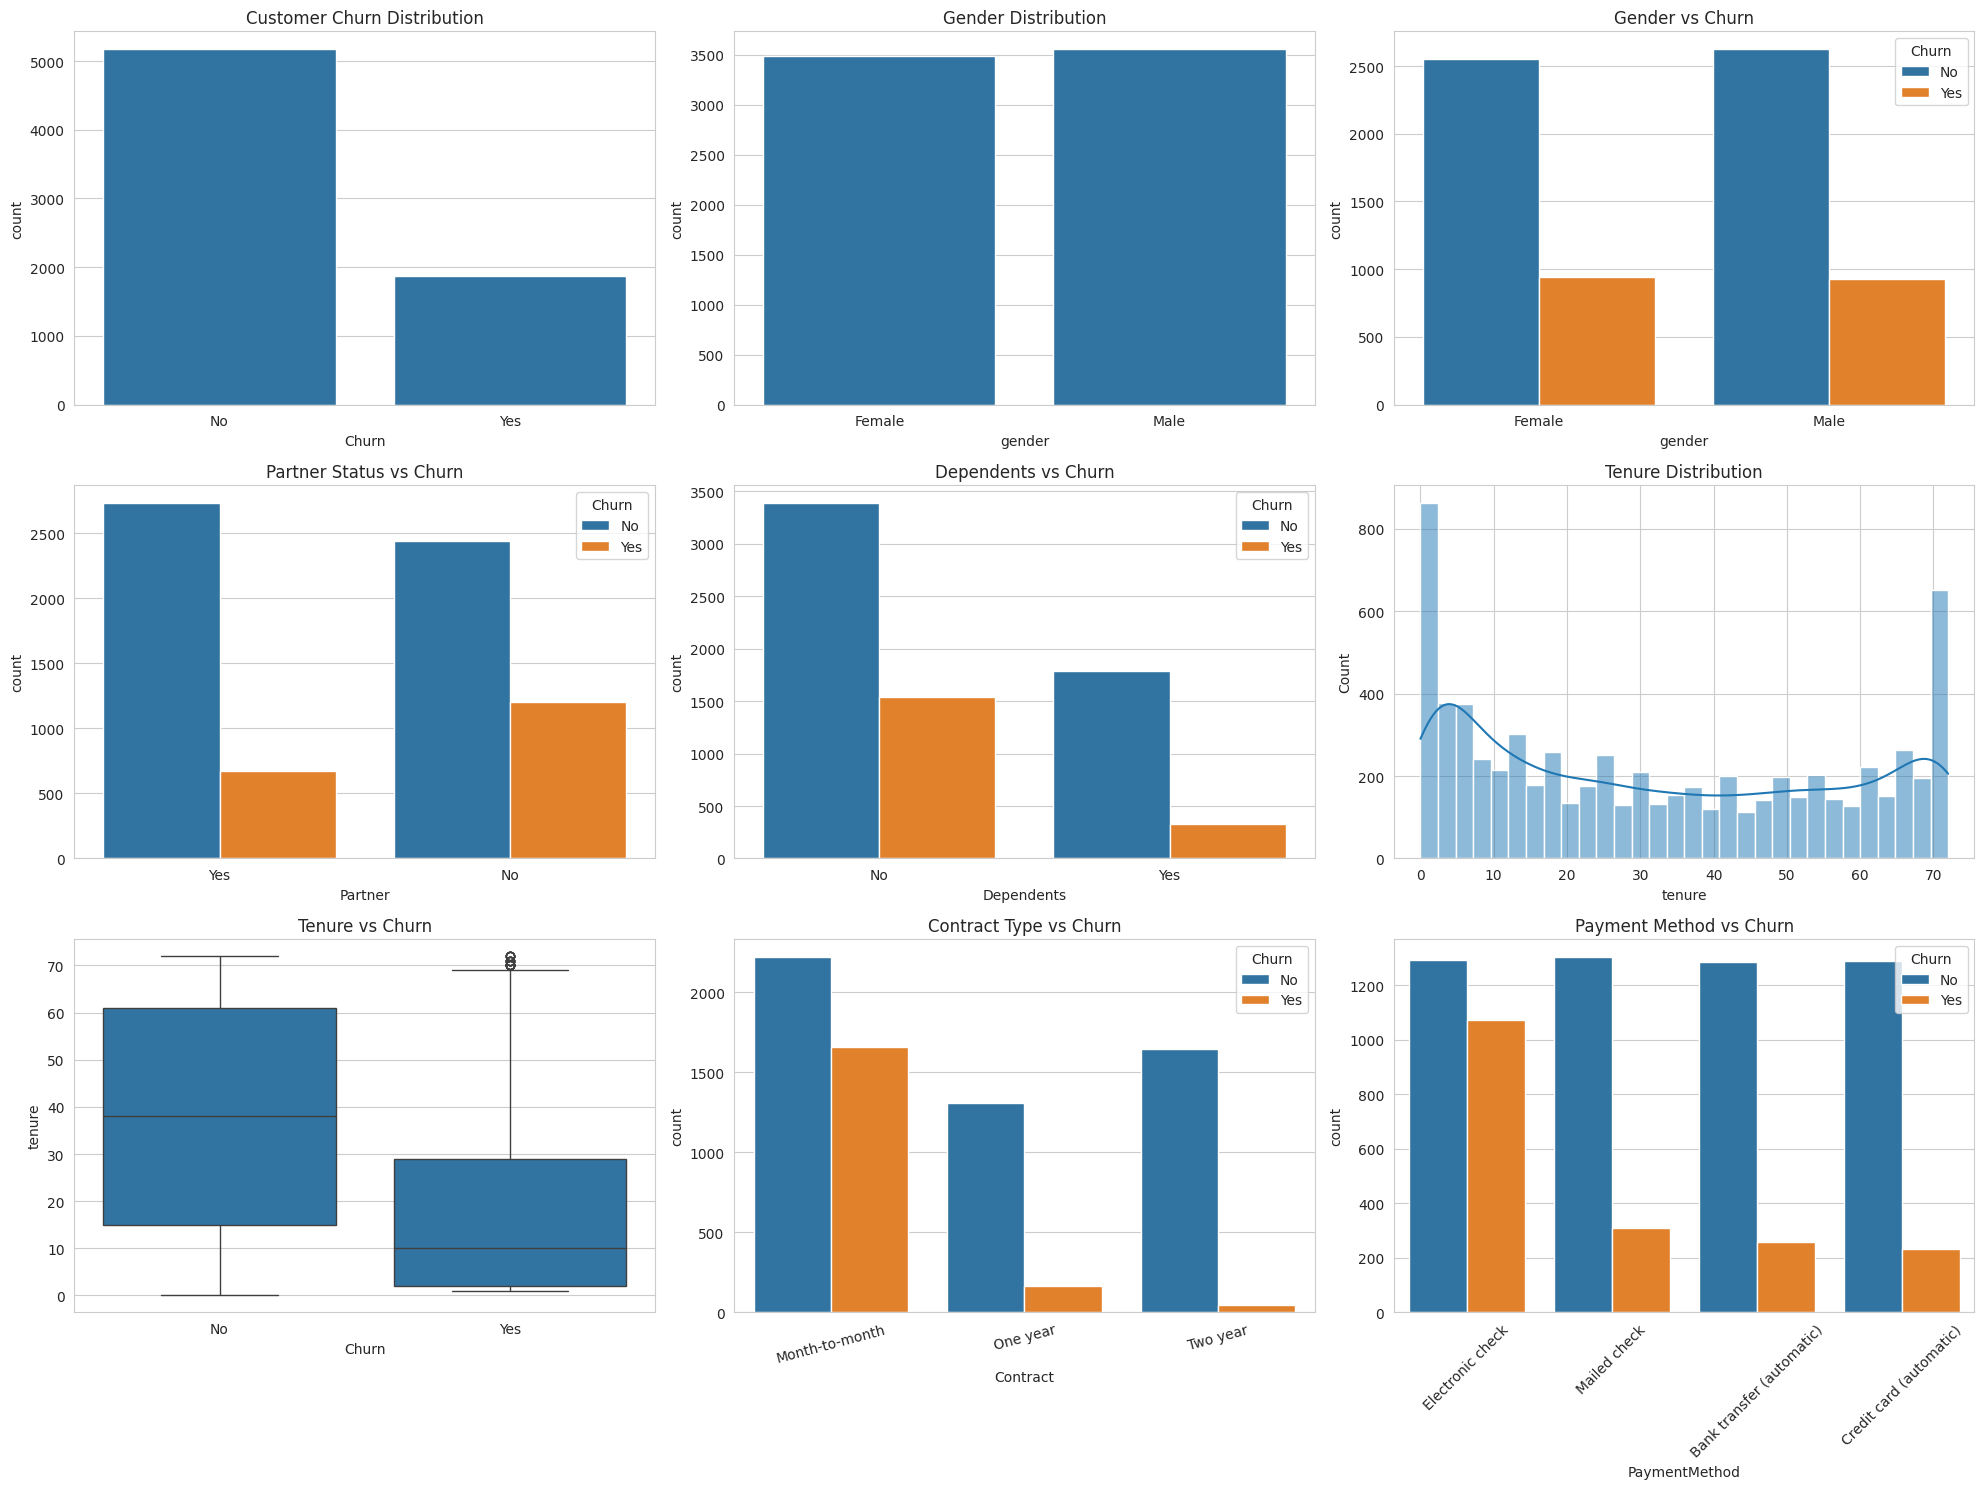

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Create a 3x3 grid of plots
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

# 1. Churn Distribution
sns.countplot(data=ccd, x='Churn', ax=axes[0,0])
axes[0,0].set_title('Customer Churn Distribution')

# 2. Gender Distribution
sns.countplot(data=ccd, x='gender', ax=axes[0,1])
axes[0,1].set_title('Gender Distribution')

# 3. Gender vs Churn
sns.countplot(data=ccd, x='gender', hue='Churn', ax=axes[0,2])
axes[0,2].set_title('Gender vs Churn')

# 4. Partner vs Churn
sns.countplot(data=ccd, x='Partner', hue='Churn', ax=axes[1,0])
axes[1,0].set_title('Partner Status vs Churn')

# 5. Dependents vs Churn
sns.countplot(data=ccd, x='Dependents', hue='Churn', ax=axes[1,1])
axes[1,1].set_title('Dependents vs Churn')

# 6. Tenure Distribution
sns.histplot(ccd['tenure'], bins=30, kde=True, ax=axes[1,2])
axes[1,2].set_title('Tenure Distribution')

# 7. Tenure vs Churn
sns.boxplot(data=ccd, x='Churn', y='tenure', ax=axes[2,0])
axes[2,0].set_title('Tenure vs Churn')

# 8. Contract Type vs Churn
sns.countplot(data=ccd, x='Contract', hue='Churn', ax=axes[2,1])
axes[2,1].set_title('Contract Type vs Churn')
axes[2,1].tick_params(axis='x', rotation=15)

# 9. Payment Method vs Churn
sns.countplot(data=ccd, x='PaymentMethod', hue='Churn', ax=axes[2,2])
axes[2,2].set_title('Payment Method vs Churn')
axes[2,2].tick_params(axis='x', rotation=45)

# Adjust spacing
plt.tight_layout()

# Save image (optional)
plt.savefig(r'/content/drive/MyDrive/Google Colab/Saiket_Internship/images/EDA_Churn_Analysis.png', dpi=300, bbox_inches='tight')

plt.show()

In [83]:
contract_churn = pd.crosstab(ccd['Contract'], ccd['Churn'], normalize='index') * 100
payment_churn = pd.crosstab(ccd['PaymentMethod'], ccd['Churn'], normalize='index') * 100
partner_churn = pd.crosstab(ccd['Partner'], ccd['Churn'], normalize='index') * 100
dependents_churn = pd.crosstab(ccd['Dependents'], ccd['Churn'], normalize='index') * 100

print("--- Contract vs Churn ---")
print(contract_churn)
print("\n--- Payment Method vs Churn ---")
print(payment_churn)
print("\n--- Partner vs Churn ---")
print(partner_churn)
print("\n--- Dependents vs Churn ---")
print(dependents_churn)

contract_churn.to_csv(r'/content/drive/MyDrive/Google Colab/Saiket_Internship/datasets/contract_churn_table.csv')
payment_churn.to_csv(r'/content/drive/MyDrive/Google Colab/Saiket_Internship/datasets/payment_churn_table.csv')
partner_churn.to_csv(r'/content/drive/MyDrive/Google Colab/Saiket_Internship/datasets/partner_churn_table.csv')
dependents_churn.to_csv(r'/content/drive/MyDrive/Google Colab/Saiket_Internship/datasets/dependents_churn_table.csv')

--- Contract vs Churn ---
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858

--- Payment Method vs Churn ---
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700

--- Partner vs Churn ---
Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903

--- Dependents vs Churn ---
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


In [84]:
#Task 3: Customer Segmentation

In [85]:
# Create tenure segments

ccd['TenureGroup'] = pd.cut(
    ccd['tenure'],
    bins=[0, 12, 48, 72],
    labels=['New', 'Mid-Term', 'Long-Term'],
    include_lowest=True
)

ccd[['tenure', 'TenureGroup']].head()

ccd.to_csv(r'/content/drive/MyDrive/Google Colab/Saiket_Internship/datasets/Tenure_Segment_Data.csv', index=False)

In [86]:
# Create monthly charge segments

ccd['ChargeGroup'] = pd.qcut(
    ccd['MonthlyCharges'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

ccd[['MonthlyCharges', 'ChargeGroup']].head()

ccd.to_csv(r'/content/drive/MyDrive/Google Colab/Saiket_Internship/datasets/Monthly_Charge_Segment_Data.csv', index=False)

In [87]:
tenure_churn = pd.crosstab(
    ccd['TenureGroup'],
    ccd['Churn'],
    normalize='index'
) * 100

print(tenure_churn)

Churn               No        Yes
TenureGroup                      
New          52.561757  47.438243
Mid-Term     76.355997  23.644003
Long-Term    90.486824   9.513176


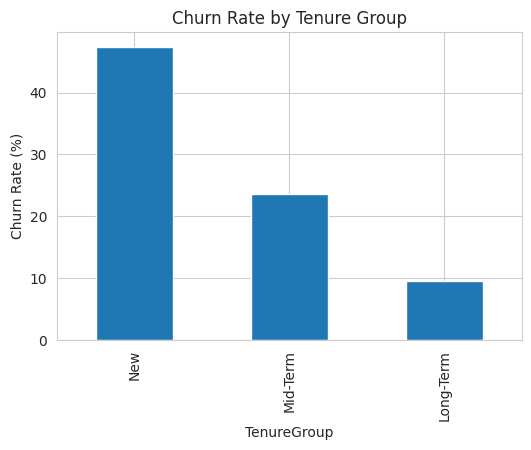

In [88]:
tenure_churn['Yes'].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.show()

In [89]:
charge_churn = pd.crosstab(
    ccd['ChargeGroup'],
    ccd['Churn'],
    normalize='index'
) * 100

print(charge_churn)

Churn               No        Yes
ChargeGroup                      
Low          84.134411  15.865589
Medium       70.319829  29.680171
High         65.913933  34.086067


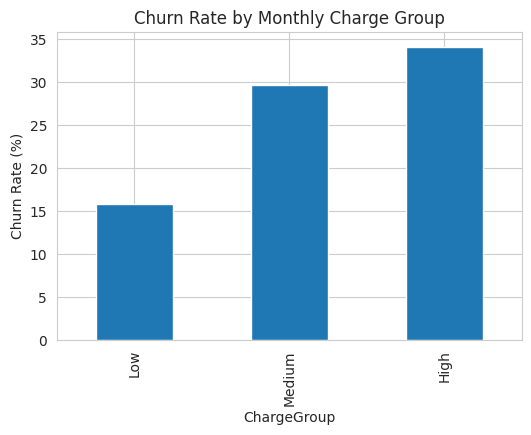

In [90]:
charge_churn['Yes'].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Churn Rate by Monthly Charge Group')
plt.ylabel('Churn Rate (%)')
plt.show()

In [91]:
contract_churn = pd.crosstab(
    ccd['Contract'],
    ccd['Churn'],
    normalize='index'
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


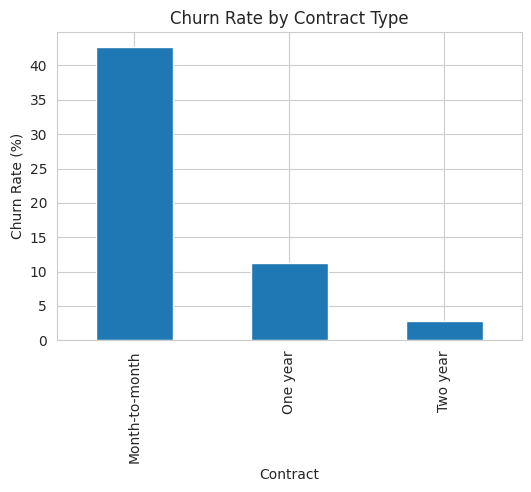

In [92]:
contract_churn['Yes'].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.show()

In [93]:
high_value_customers = ccd[
    (ccd['ChargeGroup'] == 'High') &
    (ccd['TenureGroup'] == 'Long-Term')
]

print(high_value_customers.shape)

(1095, 23)


In [94]:
at_risk_high_value = high_value_customers[
    high_value_customers['Churn'] == 'Yes'
]

print(at_risk_high_value.shape)

at_risk_high_value.head()

(166, 23)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ChargeGroup
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,Long-Term,High
104,3192-NQECA,Male,0,Yes,No,68,Yes,Yes,Fiber optic,No,...,Yes,Yes,Two year,Yes,Bank transfer (automatic),110.00,7611.85,Yes,Long-Term,High
110,0486-HECZI,Male,0,Yes,No,55,Yes,Yes,Fiber optic,Yes,...,Yes,No,Month-to-month,Yes,Electronic check,96.75,5238.90,Yes,Long-Term,High
173,0691-JVSYA,Female,0,Yes,No,53,Yes,No,Fiber optic,No,...,Yes,Yes,One year,Yes,Bank transfer (automatic),94.85,5000.20,Yes,Long-Term,High
276,4484-GLZOU,Female,0,Yes,No,52,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,105.05,5624.85,Yes,Long-Term,High


In [95]:
risk_rate = (
    at_risk_high_value.shape[0] /
    high_value_customers.shape[0]
) * 100

print(f"High-Value Customer Churn Rate: {risk_rate:.2f}%")

High-Value Customer Churn Rate: 15.16%


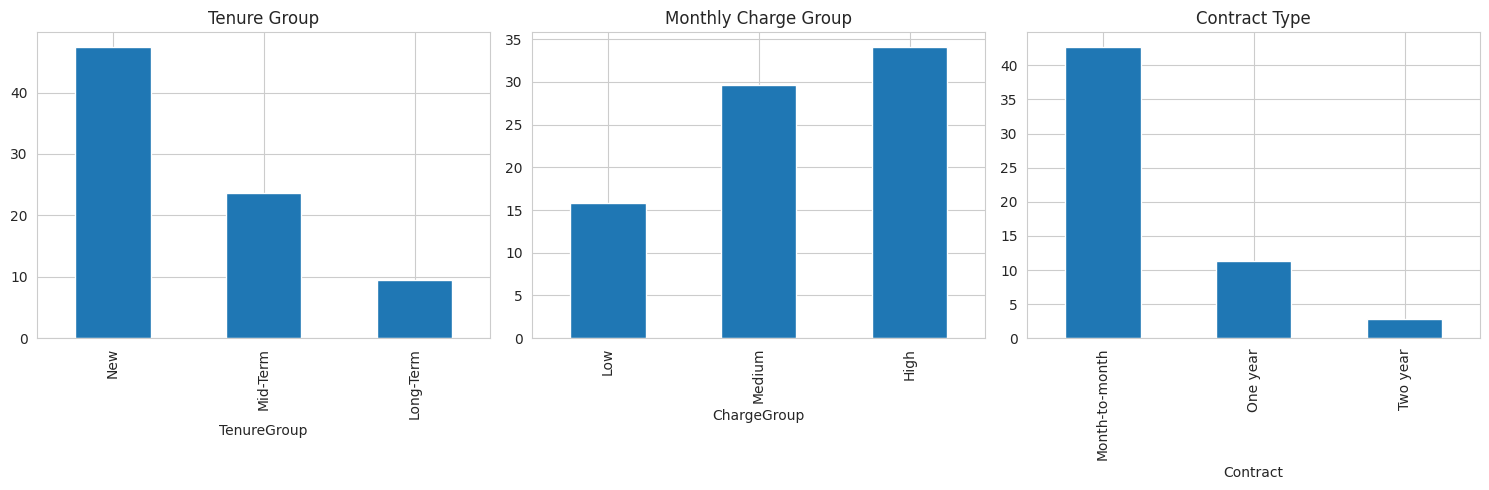

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

tenure_churn['Yes'].plot(
    kind='bar',
    ax=axes[0],
    title='Tenure Group'
)

charge_churn['Yes'].plot(
    kind='bar',
    ax=axes[1],
    title='Monthly Charge Group'
)

contract_churn['Yes'].plot(
    kind='bar',
    ax=axes[2],
    title='Contract Type'
)

plt.tight_layout()
plt.savefig(r'/content/drive/MyDrive/Google Colab/Saiket_Internship/images/EDA_ChurnGroup_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [97]:
#Task4

In [98]:
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [99]:
# Initialize model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [100]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create a table of evaluation metrics
lr_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [
        accuracy_score(y_test, lr_pred),
        precision_score(y_test, lr_pred),
        recall_score(y_test, lr_pred),
        f1_score(y_test, lr_pred)
    ]
})

# Display the table
print(lr_results)

# Save to CSV
lr_results.to_csv(r'/content/drive/MyDrive/Google Colab/Saiket_Internship/datasets/Logistic_Regression_Metrics.csv', index=False)

      Metric     Value
0   Accuracy  0.803407
1  Precision  0.652038
2     Recall  0.556150
3   F1 Score  0.600289


In [101]:
# Initialize model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

In [102]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create a table of evaluation metrics
dt_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [
        accuracy_score(y_test, dt_pred),
        precision_score(y_test, dt_pred),
        recall_score(y_test, dt_pred),
        f1_score(y_test, dt_pred)
    ]
})

# Display the table
print(dt_results)

# Save to CSV
dt_results.to_csv(r'/content/drive/MyDrive/Google Colab/Saiket_Internship/datasets/Decision_Tree_Metrics.csv', index=False)

      Metric     Value
0   Accuracy  0.741661
1  Precision  0.513889
2     Recall  0.494652
3   F1 Score  0.504087


In [103]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Decision Tree'],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred)
    ],

    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred)
    ]
})

# Display the table
print(results)

# Save to CSV
results.to_csv(r'/content/drive/MyDrive/Google Colab/Saiket_Internship/datasets/Model_Comparison_Metrics.csv', index=False)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.803407   0.652038  0.556150  0.600289
1        Decision Tree  0.741661   0.513889  0.494652  0.504087


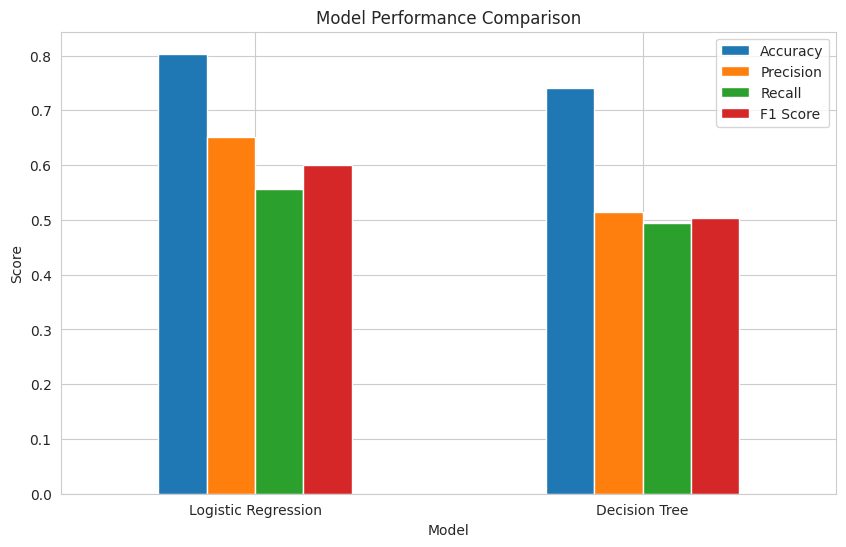

In [104]:
results.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)

plt.savefig(r'/content/drive/MyDrive/Google Colab/Saiket_Internship/images/Model_Performance_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [105]:
# Feature importance from Logistic Regression

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

feature_importance['Absolute_Coefficient'] = abs(
    feature_importance['Coefficient']
)

feature_importance = feature_importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

print(feature_importance.head(10))

                           Feature  Coefficient  Absolute_Coefficient
25               Contract_Two year    -1.341428              1.341428
10     InternetService_Fiber optic     0.750786              0.750786
24               Contract_One year    -0.688539              0.688539
7                 PhoneService_Yes    -0.449184              0.449184
13              OnlineSecurity_Yes    -0.431101              0.431101
28  PaymentMethod_Electronic check     0.387788              0.387788
19                 TechSupport_Yes    -0.381696              0.381696
26            PaperlessBilling_Yes     0.377059              0.377059
9                MultipleLines_Yes     0.275753              0.275753
6                   Dependents_Yes    -0.224504              0.224504


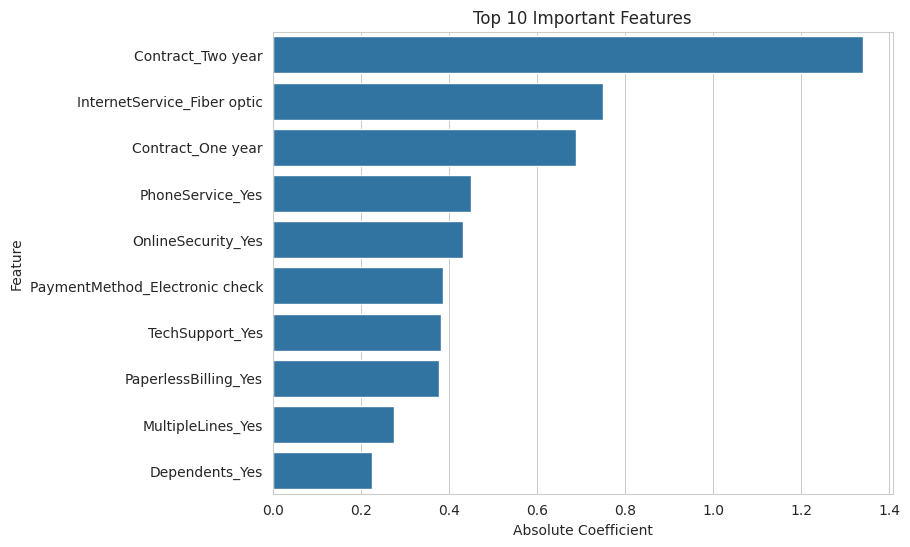

In [106]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_features,
    x='Absolute_Coefficient',
    y='Feature'
)

plt.title('Top 10 Important Features')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')

# Save the plot
plt.savefig(r'/content/drive/MyDrive/Google Colab/Saiket_Internship/images/Top_10_Feature_Importance.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

In [107]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

# Grid Search
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1'
)

# Fit
grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

# Best score
print("Best Cross-Validation F1 Score:", grid.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best Parameters: {'C': 10, 'solver': 'lbfgs'}
Best Cross-Validation F1 Score: 0.5983013077236646


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [108]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create a table of evaluation metrics
best_lr_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [
        accuracy_score(y_test, best_pred),
        precision_score(y_test, best_pred),
        recall_score(y_test, best_pred),
        f1_score(y_test, best_pred)
    ]
})

# Display the table
print(best_lr_results)

# Save to CSV
best_lr_results.to_csv(r'/content/drive/MyDrive/Google Colab/Saiket_Internship/datasets/Tuned_Logistic_Regression_Metrics.csv',
    index=False)

      Metric     Value
0   Accuracy  0.805536
1  Precision  0.657233
2     Recall  0.558824
3   F1 Score  0.604046


In [109]:
#Task 5

In [110]:
# Predicted probabilities for the positive class (Churn = Yes)
y_prob = best_lr.predict_proba(X_test)[:, 1]

In [111]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.8410808855821643


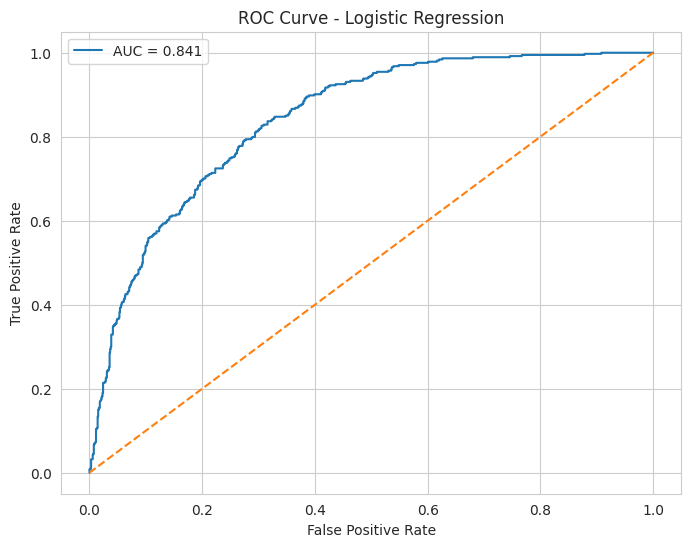

In [112]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         label=f'AUC = {auc_score:.3f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

# Save the plot
plt.savefig(r"/content/drive/MyDrive/Google Colab/Saiket_Internship/images/ROC_Curve.png", dpi=300, bbox_inches="tight")

plt.show()